# Notebook 02: Preprocessing & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Data

In [3]:
weekly = pd.read_csv('clean_data/weekly_agg_sales.csv', parse_dates=['week_start'])

calendar = pd.read_csv('data/calendar.csv', parse_dates=['date'])
sell_prices = pd.read_csv('data/sell_prices.csv')
sales_train_eval = pd.read_csv('data/sales_train_evaluation.csv')

weekly.head()

,store_id,state_id,cat_id,wm_yr_wk,weekly_units,week_start,n_days,month
0,CA_1,CA,FOODS,11101,17774,2011-01-29,7,1
1,CA_1,CA,FOODS,11102,18319,2011-02-05,7,2
2,CA_1,CA,FOODS,11103,15515,2011-02-12,7,2
3,CA_1,CA,FOODS,11104,14860,2011-02-19,7,2
4,CA_1,CA,FOODS,11105,15253,2011-02-26,7,2


In [4]:
weekly = weekly[weekly['n_days'] == 7].copy()
weekly = weekly.sort_values(['store_id', 'cat_id', 'week_start']).reset_index(drop=True)

## 2. Feature Engineering

### 2.1 Lag Features
From the autocorrelation plots: lag-1 is strong across all categories, lag-2 helps capture the biweekly pattern in Foods.

In [5]:
for lag in [1, 2, 4]:
    weekly[f'lag_{lag}'] = (
        weekly.groupby(['store_id', 'cat_id'])['weekly_units']
        .shift(lag)
    )

weekly['lag_52'] = (
    weekly.groupby(['store_id', 'cat_id'])['weekly_units']
    .shift(52)
)

### 2.2 Rolling Statistics & Derived Signals

In [7]:
# Rolling stats — shift(1) so we only use info available BEFORE the week we're predicting
grp = weekly.groupby(['store_id', 'cat_id'])['weekly_units']

weekly['rolling_mean_4'] = grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
weekly['rolling_std_4']  = grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).std())
weekly['rolling_mean_8'] = grp.transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())

weekly['momentum'] = weekly['lag_1'] - weekly['lag_2']

weekly['recent_cv'] = weekly['rolling_std_4'] / weekly['rolling_mean_4']

### 2.3 Calendar Features

In [8]:
weekly['month'] = weekly['week_start'].dt.month
weekly['week_of_year'] = weekly['week_start'].dt.isocalendar().week.astype(int)

# Cyclical encoding to treat Jan-December as close
weekly['month_sin'] = np.sin(2 * np.pi * weekly['month'] / 12)
weekly['month_cos'] = np.cos(2 * np.pi * weekly['month'] / 12)
weekly['woy_sin']   = np.sin(2 * np.pi * weekly['week_of_year'] / 52)
weekly['woy_cos']   = np.cos(2 * np.pi * weekly['week_of_year'] / 52)

day_of_month = weekly['week_start'].dt.day
weekly['near_payday'] = ((day_of_month <= 7) | ((day_of_month >= 15) & (day_of_month <= 21))).astype(int)

min_date = weekly['week_start'].min()
weekly['time_index'] = (weekly['week_start'] - min_date).dt.days / 365.25  # in fractional years

### 2.4 Event Features

In [9]:
cal_events = calendar[['wm_yr_wk', 'event_type_1']].copy()
cal_events['is_national'] = (cal_events['event_type_1'] == 'National').astype(int)
cal_events['is_other_event'] = (cal_events['event_type_1'].notna() & (cal_events['event_type_1'] != 'National')).astype(int)

events_per_week = (
    cal_events
    .groupby('wm_yr_wk')[['is_national', 'is_other_event']]
    .sum()
    .rename(columns={'is_national': 'national_events', 'is_other_event': 'other_events'})
    .reset_index()
)

weekly = weekly.merge(events_per_week, on='wm_yr_wk', how='left')
weekly[['national_events', 'other_events']] = weekly[['national_events', 'other_events']].fillna(0)

### 2.5 SNAP Features

In [10]:
# SNAP days per week per state
snap_per_week = (
    calendar
    .groupby('wm_yr_wk')[['snap_CA', 'snap_TX', 'snap_WI']]
    .sum()
    .reset_index()
)

weekly = weekly.merge(snap_per_week, on='wm_yr_wk', how='left')

weekly['snap_days'] = np.where(
    weekly['state_id'] == 'CA', weekly['snap_CA'],
    np.where(weekly['state_id'] == 'TX', weekly['snap_TX'], weekly['snap_WI'])
)

weekly = weekly.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'])

### 2.6 Price Features

In [11]:
item_cat = sales_train_eval[['item_id', 'cat_id']].drop_duplicates()
prices_with_cat = sell_prices.merge(item_cat, on='item_id', how='left')

avg_price = (
    prices_with_cat
    .groupby(['store_id', 'cat_id', 'wm_yr_wk'])['sell_price']
    .mean()
    .reset_index()
    .rename(columns={'sell_price': 'avg_price'})
)

weekly = weekly.merge(avg_price, on=['store_id', 'cat_id', 'wm_yr_wk'], how='left')
weekly = weekly.sort_values(['store_id', 'cat_id', 'week_start'])

weekly['price_rolling_4'] = (
    weekly.groupby(['store_id', 'cat_id'])['avg_price']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# "Is this week cheap or expensive?" price relative to its own recent average
# Negative = on sale compared to recent weeks, positive = more expensive
weekly['price_relative'] = (weekly['avg_price'] - weekly['price_rolling_4']) / weekly['price_rolling_4']

### 2.7 Cross-Series Features

In [12]:
store_totals = (
    weekly.groupby(['store_id', 'wm_yr_wk'])['weekly_units']
    .sum()
    .reset_index(name='store_total')
)
weekly = weekly.merge(store_totals, on=['store_id', 'wm_yr_wk'], how='left')

weekly = weekly.sort_values(['store_id', 'cat_id', 'week_start'])
weekly['store_traffic_lag1'] = (
    weekly.groupby(['store_id', 'cat_id'])['store_total']
    .shift(1)
)
weekly = weekly.drop(columns=['store_total'])
weekly['cat_share_lag1'] = weekly['lag_1'] / weekly['store_traffic_lag1']

print("Cross-series features:")
print(weekly[['store_traffic_lag1', 'cat_share_lag1']].describe().round(3))

Cross-series features:
       store_traffic_lag1  cat_share_lag1
count            8280.000        8280.000
mean            24097.586           0.333
std              8069.972           0.257
min              8256.000           0.030
25%             18847.500           0.115
50%             22953.500           0.216
75%             28186.000           0.651
max             53713.000           0.830


### 2.8 Categorical Encoding

In [13]:
weekly = pd.get_dummies(weekly, columns=['cat_id', 'store_id', 'state_id'], dtype=int)

## 3. Handle Missing Values

Lag and rolling features introduce NaNs at the start of each series. We drop those rows since we can't use them for training without leaking information.

In [14]:
missing = weekly.isna().sum()
print(missing[missing > 0])

weekly = weekly.dropna().reset_index(drop=True)
print(f"Rows after:  {weekly.shape[0]}")

lag_1                   30
lag_2                   60
lag_4                  120
lag_52                1560
rolling_mean_4          30
rolling_std_4           60
rolling_mean_8          30
momentum                60
recent_cv               60
store_traffic_lag1      30
cat_share_lag1          30
dtype: int64
Rows after:  6750


## 4. Feature Overview

In [15]:
target = 'weekly_units'
id_cols = ['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year']
feature_cols = [c for c in weekly.columns if c != target and c not in id_cols]

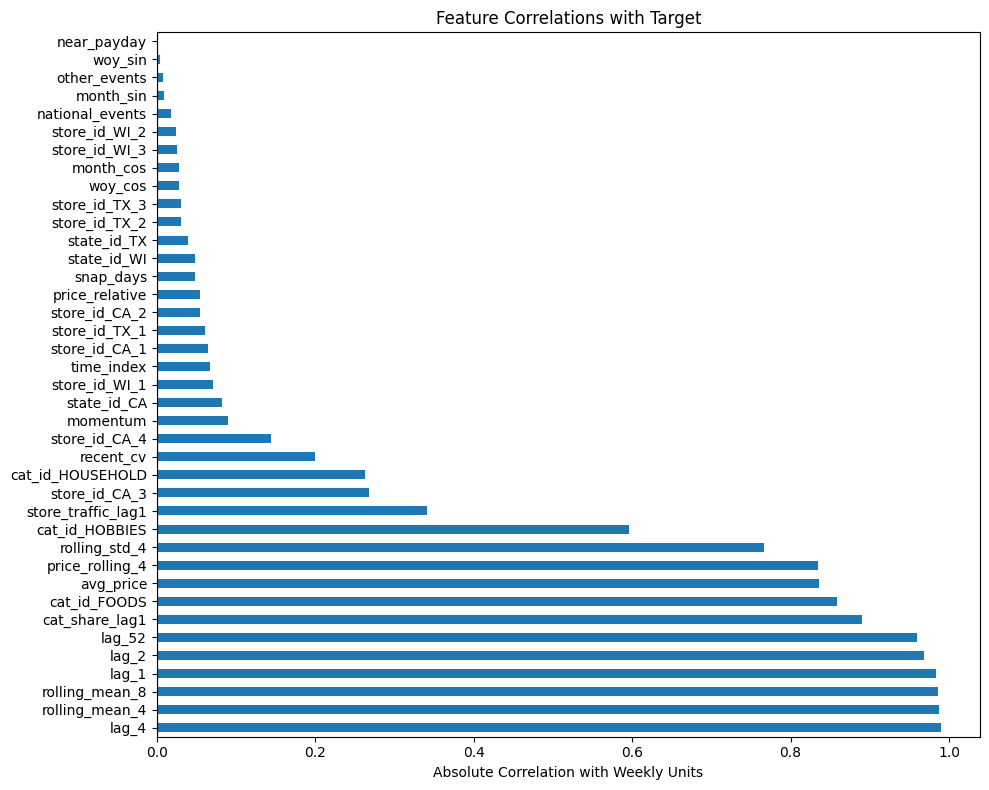

In [19]:
corr_with_target = np.abs(weekly[feature_cols + [target]].corr()[target].drop(target)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot(kind='barh', ax=ax)
ax.set_xlabel('Absolute Correlation with Weekly Units')
ax.set_title('Feature Correlations with Target')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Train / Test Split

Time-based split: we hold out the **last 8 weeks** (~2 months) as the test set. This mimics the real forecasting scenario — we never train on future data.

In [20]:
split_weeks = 8
sorted_weeks = sorted(weekly['wm_yr_wk'].unique())
test_weeks = sorted_weeks[-split_weeks:]
train_weeks = sorted_weeks[:-split_weeks]

train = weekly[weekly['wm_yr_wk'].isin(train_weeks)].copy()
test = weekly[weekly['wm_yr_wk'].isin(test_weeks)].copy()


X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]


## 6. Save Processed Data

In [21]:
train.to_csv('clean_data/train.csv', index=False)
test.to_csv('clean_data/test.csv', index=False)
weekly.to_csv('clean_data/weekly_features.csv', index=False)